# Cantor Set Reconstruction — Paper II, Example 6.2

This notebook demonstrates numerically the Cantor set reconstruction example from Paper II
(*Dynamics and Reconstruction in the Observable Measure*, §6).

**Mathematical setup.**  
Let $\mathcal{C} \subset [0,1]$ be the middle-thirds Cantor set, coded by ternary sequences
over $\{0,2\}^{\mathbb{N}}$ via $\pi(d_1,d_2,\ldots) = \sum_{k\geq 1} d_k/3^k$.  
The Cantor measure $\mu_{\mathcal{C}}$ is the pushforward of the fair-coin product measure
$\nu = (\tfrac{1}{2}\delta_0 + \tfrac{1}{2}\delta_2)^{\mathbb{N}}$.  
The shift map $S: \mathcal{C} \to \mathcal{C}$ acts as left-shift on the digit sequence:
$S(\pi(d_1,d_2,\ldots)) = \pi(d_2,d_3,\ldots)$.

The delay embedding at lag $L$ is
$$
  \Phi_h^{(L)}(x) = (x,\, Sx,\, S^2 x,\, \ldots,\, S^L x) \in [0,1]^{L+1}.
$$
Each coordinate reads off a successive digit: $S^n x$ recovers digit $d_{n+1}$.  
The fibres of $\Phi_h^{(L)}$ are the generation-$(L+1)$ cylinder sets,
each with $\mu_{\mathcal{C}}$-measure $2^{-(L+1)}$.  
As $L \to \infty$ the fibres shrink to singletons (a.e.), so the observable algebra
$\mathcal{O}_h = \sigma\bigl(\bigcup_L \mathcal{O}_h^{(L)}\bigr) = \mathcal{B}(\mathcal{C})$
mod $\mu_{\mathcal{C}}$, and $\Phi_h$ is a measure-theoretic embedding.

**Four panels below.**
1. Construction of $\mathcal{C}$ via successive removal of middle thirds.
2. Delay embedding cloud $(x, Sx)$ for many sample points — a fractal subset of $[0,1]^2$.
3. Fibre refinement: cylinder partition of $\mathcal{C}$ at lags $L = 1,2,3,4$.
4. Reconstruction convergence for a single test point — fibre diameter shrinking as $L$ grows.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib.cm as cm

rng = np.random.default_rng(42)

# ── Sampling from μ_C ─────────────────────────────────────────────────────────
# A point x ~ μ_C is generated by drawing d_1, d_2, ... iid Uniform({0,2})
# and computing x = sum d_k / 3^k.

def sample_cantor(n_points, n_digits=40, rng=rng):
    """Sample n_points from the Cantor measure using n_digits ternary digits."""
    digits = rng.choice([0, 2], size=(n_points, n_digits))  # shape (n, d)
    powers = 3.0 ** -np.arange(1, n_digits + 1)             # 1/3, 1/9, ...
    return digits @ powers, digits                           # x values + raw digits

def shift_n(digits, n):
    """Apply S^n: drop first n digits, re-encode (pad with 0 — negligible for large n_digits)."""
    shifted = digits[:, n:]                                  # drop first n digits
    powers = 3.0 ** -np.arange(1, shifted.shape[1] + 1)
    return shifted @ powers

print("Utilities defined.")

Utilities defined.


## Panel 1 — Construction of $\mathcal{C}$

Each row shows the intervals remaining after $k$ steps of middle-third removal.
The Cantor set is the intersection of all rows.

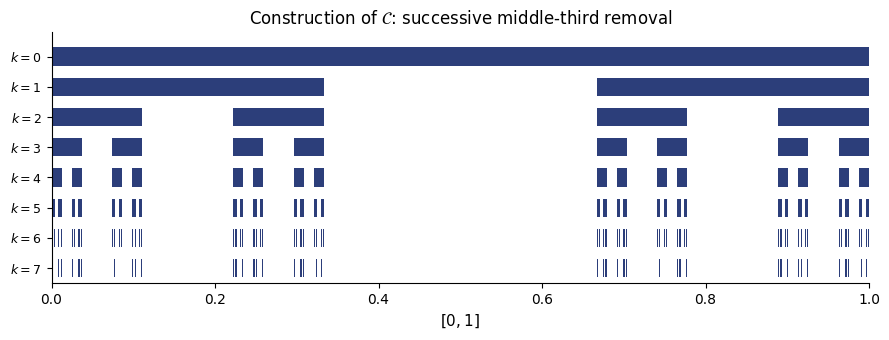

In [2]:
def cantor_intervals(depth):
    """Return list of (left, right) intervals remaining after `depth` removals."""
    intervals = [(0.0, 1.0)]
    for _ in range(depth):
        new = []
        for a, b in intervals:
            third = (b - a) / 3
            new.append((a, a + third))
            new.append((b - third, b))
        intervals = new
    return intervals

fig, ax = plt.subplots(figsize=(9, 3.5))
n_levels = 7
for level in range(n_levels + 1):
    ivs = cantor_intervals(level)
    y = n_levels - level
    for a, b in ivs:
        ax.barh(y, b - a, left=a, height=0.6, color='#2c3e7a', linewidth=0)

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, n_levels + 0.8)
ax.set_yticks(range(n_levels + 1))
ax.set_yticklabels([f'$k={n_levels - i}$' for i in range(n_levels + 1)], fontsize=9)
ax.set_xlabel('$[0,1]$', fontsize=11)
ax.set_title('Construction of $\\mathcal{C}$: successive middle-third removal', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Panel 2 — Delay embedding cloud $(x, Sx)$

The image of $\Phi_h^{(1)}: x \mapsto (x, Sx)$ is a fractal subset of $[0,1]^2$:
four clusters at the four possible first-digit pairs $(d_1,d_2) \in \{0,2\}^2$.
Colouring by a third lag $S^2 x$ shows the self-similar sub-clustering.

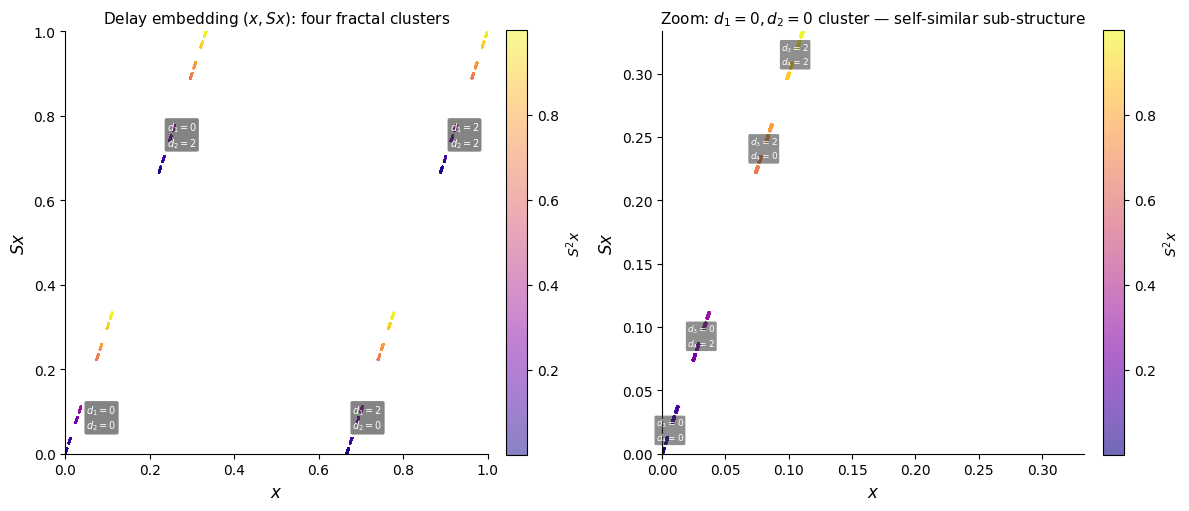

Cluster bounding boxes (full cloud):
     (d1,d2)                 x range                Sx range
  (0,0):  24903pts  x∈[0.0000,0.1111]  Sx∈[0.0000,0.3333]
  (0,2):  24903pts  x∈[0.2222,0.3333]  Sx∈[0.6667,1.0000]
  (2,0):  24903pts  x∈[0.6667,0.7778]  Sx∈[0.0000,0.3333]
  (2,2):  24903pts  x∈[0.8889,1.0000]  Sx∈[0.6667,1.0000]


In [3]:
N = 100_000
xs, digits = sample_cantor(N)
Sx  = shift_n(digits, 1)
S2x = shift_n(digits, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# ── Left: full embedding cloud ────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(xs, Sx, c=S2x, s=2.5, cmap='plasma', alpha=0.5, linewidths=0)
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('$S^2 x$', fontsize=10)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$Sx$', fontsize=12)
ax.set_title('Delay embedding $(x, Sx)$: four fractal clusters', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
# annotate four clusters
for (d1, d2, lx, ly) in [(0,0,0.05,0.05),(0,2,0.24,0.72),(2,0,0.68,0.05),(2,2,0.91,0.72)]:
    ax.text(lx, ly, f'$d_1={d1}$\n$d_2={d2}$', fontsize=7, color='white',
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', fc='#333333', alpha=0.6, lw=0))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Right: zoom into bottom-left cluster (d1=0, d2=0) ────────────────────────
ax2 = axes[1]
mask = (digits[:,0] == 0) & (digits[:,1] == 0)
xs_z, Sx_z, S2x_z = xs[mask], Sx[mask], S2x[mask]
sc2 = ax2.scatter(xs_z, Sx_z, c=S2x_z, s=5, cmap='plasma', alpha=0.6, linewidths=0)
cbar2 = fig.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('$S^2 x$', fontsize=10)
ax2.set_xlabel('$x$', fontsize=12)
ax2.set_ylabel('$Sx$', fontsize=12)
ax2.set_title('Zoom: $d_1=0, d_2=0$ cluster — self-similar sub-structure', fontsize=11)
ax2.set_xlim(0, 1/3); ax2.set_ylim(0, 1/3); ax2.set_aspect('equal')
# four sub-clusters from (d3,d4)
for (d3, d4) in [(0,0),(0,2),(2,0),(2,2)]:
    m = mask & (digits[:,2]==d3) & (digits[:,3]==d4)
    if m.any():
        cx, cy = xs[m].mean(), Sx[m].mean()
        ax2.text(cx, cy, f'$d_3={d3}$\n$d_4={d4}$', fontsize=6.5, color='white',
                 va='center', ha='center',
                 bbox=dict(boxstyle='round,pad=0.15', fc='#333333', alpha=0.55, lw=0))
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("Cluster bounding boxes (full cloud):")
print(f"  {'(d1,d2)':>10}  {'x range':>22}  {'Sx range':>22}")
for d1 in [0, 2]:
    for d2 in [0, 2]:
        m = (digits[:,0] == d1) & (digits[:,1] == d2)
        print(f"  ({d1},{d2}): {mask.sum():>6}pts  "
              f"x∈[{xs[m].min():.4f},{xs[m].max():.4f}]  "
              f"Sx∈[{Sx[m].min():.4f},{Sx[m].max():.4f}]")


## Panel 3 — Fibre refinement

The generation-$(L+1)$ cylinder sets partition $\mathcal{C}$ into $2^{L+1}$ pieces,
each with $\mu_{\mathcal{C}}$-measure $2^{-(L+1)}$.  
As $L$ grows, the fibres of $\Phi_h^{(L)}$ refine: each fibre is a cylinder set.
Below we show the partition of $\mathcal{C}$ at $L=1,2,3,4$, with colours
labelling distinct fibres.

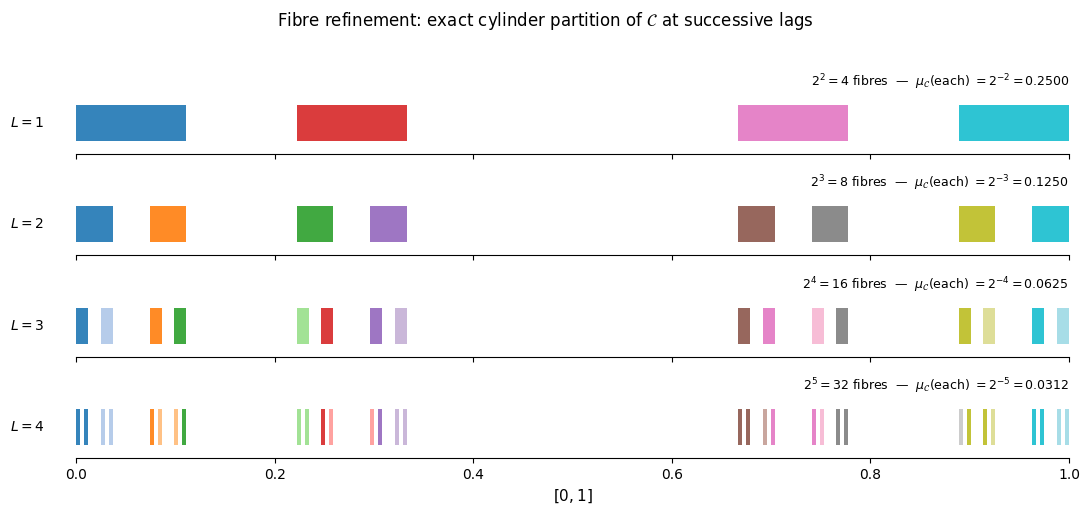

Exact cylinder intervals at L=2 (8 fibres):
  Fibre 0: [0.000000, 0.037037]  width=0.037037  μ_C = 1/8
  Fibre 1: [0.074074, 0.111111]  width=0.037037  μ_C = 1/8
  Fibre 2: [0.222222, 0.259259]  width=0.037037  μ_C = 1/8
  Fibre 3: [0.296296, 0.333333]  width=0.037037  μ_C = 1/8
  Fibre 4: [0.666667, 0.703704]  width=0.037037  μ_C = 1/8
  Fibre 5: [0.740741, 0.777778]  width=0.037037  μ_C = 1/8
  Fibre 6: [0.888889, 0.925926]  width=0.037037  μ_C = 1/8
  Fibre 7: [0.962963, 1.000000]  width=0.037037  μ_C = 1/8


In [4]:
# Use cantor_intervals to draw exact cylinder intervals as coloured bars
# rather than scattering points (which look like dashes at this scale)

fig, axes = plt.subplots(4, 1, figsize=(11, 5), sharex=True)

cmap_names = ['tab10', 'tab10', 'tab20', 'tab20']

for row, L in enumerate([1, 2, 3, 4]):
    ax = axes[row]
    n_fibres = 2 ** (L + 1)
    cmap = plt.colormaps[cmap_names[row]].resampled(n_fibres)

    # Generate all 2^{L+1} cylinder intervals exactly via cantor_intervals(L+1)
    # cantor_intervals(k) returns the 2^k surviving intervals after k removals
    ivs = cantor_intervals(L + 1)   # list of (lo, hi) — one per cylinder set
    for j, (lo, hi) in enumerate(ivs):
        colour = cmap(j / n_fibres)
        ax.barh(0, hi - lo, left=lo, height=0.7, color=colour,
                linewidth=0, alpha=0.9)

    ax.set_yticks([])
    fibre_measure = 2 ** -(L + 1)
    ax.set_ylabel(f'$L={L}$', fontsize=10, rotation=0, labelpad=35, va='center')
    ax.set_ylim(-0.6, 0.6)
    ax.set_xlim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_title(
        f'$2^{{{L+1}}}={n_fibres}$ fibres  —  ' +
        f'$\\mu_{{\\mathcal{{C}}}}$(each) $= 2^{{-{L+1}}} = {fibre_measure:.4f}$',
        fontsize=9, loc='right', pad=3)

axes[-1].set_xlabel('$[0,1]$', fontsize=11)
fig.suptitle(
    'Fibre refinement: exact cylinder partition of $\\mathcal{C}$ at successive lags',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Exact cylinder intervals at L=2 (8 fibres):")
for j,(lo,hi) in enumerate(cantor_intervals(3)):
    print(f"  Fibre {j}: [{lo:.6f}, {hi:.6f}]  width={hi-lo:.6f}  μ_C = 1/8")


## Panel 4 — Reconstruction convergence for a single test point

Fix a test point $x^* \sim \mu_{\mathcal{C}}$.  As $L$ grows, the fibre
$F_{z^*} = \{x : d_k(x) = d_k(x^*),\; 1\leq k \leq L+1\}$
containing $x^*$ shrinks geometrically: its diameter in $[0,1]$ is
at most $(2/3)^{L+1}$ (the width of a generation-$(L+1)$ Cantor interval).

We plot the fibre interval $[\inf F_{z^*}, \sup F_{z^*}]$ as $L$ varies,
showing convergence to $\{x^*\}$.

Test point x* = 0.2499731879
First 10 digits: [0, 2, 0, 2, 0, 2, 0, 2, 0, 0]


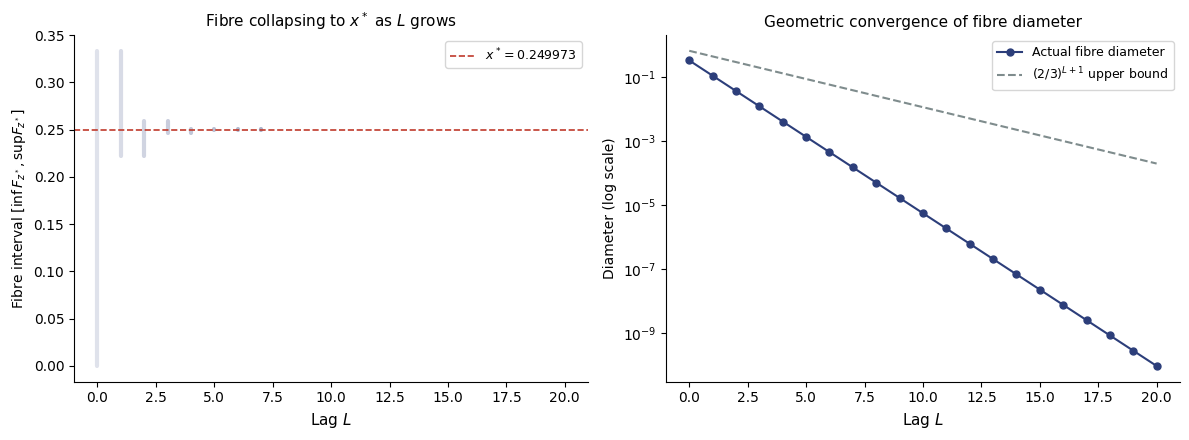


Numerical fibre diameters:
   L            diam     (2/3)^(L+1)
   0        3.33e-01        6.67e-01
   2        3.70e-02        2.96e-01
   4        4.12e-03        1.32e-01
   6        4.57e-04        5.85e-02
   8        5.08e-05        2.60e-02
  10        5.65e-06        1.16e-02
  12        6.27e-07        5.14e-03
  14        6.97e-08        2.28e-03
  16        7.74e-09        1.01e-03
  18        8.60e-10        4.51e-04
  20        9.56e-11        2.00e-04


In [5]:
# Fix a test point
x_star, d_star = sample_cantor(1, n_digits=60)
x_star = float(x_star[0])
d_star = d_star[0]  # digit sequence for x*

print(f"Test point x* = {x_star:.10f}")
print(f"First 10 digits: {d_star[:10].tolist()}")

# For each lag L, compute the fibre interval
# The fibre at lag L is determined by digits d_1,...,d_{L+1}
# Its left endpoint: replace all subsequent digits by 0
# Its right endpoint: replace all subsequent digits by 2

max_L = 20
n_digits_total = 60
lags = np.arange(0, max_L + 1)
fibre_lo = np.zeros(max_L + 1)
fibre_hi = np.zeros(max_L + 1)
fibre_diam = np.zeros(max_L + 1)

for L in lags:
    # Keep first L+1 digits, pad with 0 or 2
    d_lo = np.zeros(n_digits_total, dtype=float)
    d_hi = np.full(n_digits_total, 2.0)
    d_lo[:L+1] = d_star[:L+1]
    d_hi[:L+1] = d_star[:L+1]
    powers = 3.0 ** -np.arange(1, n_digits_total + 1)
    fibre_lo[L] = d_lo @ powers
    fibre_hi[L] = d_hi @ powers
    fibre_diam[L] = fibre_hi[L] - fibre_lo[L]

# Theoretical diameter: (2/3)^{L+1} * ... actually the fibre fits inside
# a Cantor interval of width (1/3)^{L+1}, scaled to the Cantor measure.
# The actual Euclidean diameter of the generation-(L+1) cylinder containing x*
# is at most (2/3)^{L+1} (two-thirds of 1 at each step).
theoretical_diam = (2/3) ** (lags + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: fibre interval as a function of L
for L in lags:
    alpha = 0.15 + 0.7 * (L / max_L)
    ax1.plot([L, L], [fibre_lo[L], fibre_hi[L]],
             color='#2c3e7a', linewidth=3, alpha=alpha, solid_capstyle='round')
ax1.axhline(x_star, color='#c0392b', linewidth=1.2, linestyle='--', label=f'$x^* = {x_star:.6f}$')
ax1.set_xlabel('Lag $L$', fontsize=11)
ax1.set_ylabel('Fibre interval $[\\inf F_{z^*}, \\sup F_{z^*}]$', fontsize=10)
ax1.set_title('Fibre collapsing to $x^*$ as $L$ grows', fontsize=11)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: diameter (log scale)
ax2.semilogy(lags, fibre_diam, 'o-', color='#2c3e7a', markersize=5, label='Actual fibre diameter')
ax2.semilogy(lags, theoretical_diam, '--', color='#7f8c8d', linewidth=1.5,
             label='$(2/3)^{L+1}$ upper bound')
ax2.set_xlabel('Lag $L$', fontsize=11)
ax2.set_ylabel('Diameter (log scale)', fontsize=10)
ax2.set_title('Geometric convergence of fibre diameter', fontsize=11)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\nNumerical fibre diameters:")
print(f"{'L':>4}  {'diam':>14}  {'(2/3)^(L+1)':>14}")
for L in range(0, max_L + 1, 2):
    print(f"{L:>4}  {fibre_diam[L]:>14.2e}  {theoretical_diam[L]:>14.2e}")

## Summary

The four panels make the abstract theorem visible:

| Panel | What it shows |
|-------|---------------|
| 1 | $\mathcal{C}$ itself — a compact, totally disconnected, measure-zero fractal |
| 2 | The delay embedding image $\Phi_h^{(1)}(\mathcal{C}) \subset [0,1]^2$ — four fractal clusters, one per digit pair |
| 3 | Fibre refinement: the $2^{L+1}$ cylinder sets partitioning $\mathcal{C}$ at each lag, shrinking geometrically |
| 4 | Reconstruction convergence for a single point: fibre diameter $\sim (2/3)^{L+1} \to 0$ |

**The key point** (Theorem II.5, Reconstruction Theorem): because these fibres separate points
$\mu_{\mathcal{C}}$-a.e., the observable algebra $\mathcal{O}_h$ equals $\mathcal{B}(\mathcal{C})$
mod $\mu_{\mathcal{C}}$, and $\Phi_h$ is a measure-theoretic embedding — *without any smoothness,
manifold dimension, or generic-map hypothesis.*  Takens's theorem has no domain of
application here; the reconstruction theorem does.